In [1]:
import numpy as np
import pandas as pd

In [2]:
df=pd.read_csv('quikr_car.csv')

In [3]:
df.shape

(892, 6)

In [4]:
df.head()

,name,company,year,Price,kms_driven,fuel_type
0,Hyundai Santro Xing XO eRLX Euro III,Hyundai,2007,"80,000","45,000 kms",Petrol
1,Mahindra Jeep CL550 MDI,Mahindra,2006,"4,25,000",40 kms,Diesel
2,Maruti Suzuki Alto 800 Vxi,Maruti,2018,Ask For Price,"22,000 kms",Petrol
3,Hyundai Grand i10 Magna 1.2 Kappa VTVT,Hyundai,2014,"3,25,000","28,000 kms",Petrol
4,Ford EcoSport Titanium 1.5L TDCi,Ford,2014,"5,75,000","36,000 kms",Diesel


In [5]:
df.tail()

,name,company,year,Price,kms_driven,fuel_type
887,Ta,Tara,zest,"3,10,000",NaN,NaN
888,Tata Zest XM Diesel,Tata,2018,"2,60,000","27,000 kms",Diesel
889,Mahindra Quanto C8,Mahindra,2013,"3,90,000","40,000 kms",Diesel
890,Honda Amaze 1.2 E i VTEC,Honda,2014,"1,80,000",Petrol,NaN
891,Chevrolet Sail 1.2 LT ABS,Chevrolet,2014,"1,60,000",Petrol,NaN


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 892 entries, 0 to 891
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   name        892 non-null    object
 1   company     892 non-null    object
 2   year        892 non-null    object
 3   Price       892 non-null    object
 4   kms_driven  840 non-null    object
 5   fuel_type   837 non-null    object
dtypes: object(6)
memory usage: 41.9+ KB


In [7]:
df = df[df['year'].str.isnumeric()]


In [8]:
df['year'] = df['year'].astype(int)


In [9]:
df = df[df['Price'] != 'Ask For Price']

In [10]:
df['Price'] = df['Price'].str.replace(',', '').astype(int)


In [11]:
df['kms_driven'] = df['kms_driven'].str.split().str.get(0).str.replace(',', '')

In [12]:
df = df[df['kms_driven'].str.isnumeric()]

In [13]:
df['kms_driven'] = df['kms_driven'].astype(int)


In [14]:
df = df[~df['fuel_type'].isna()]


In [15]:
df['name'] = df['name'].str.split().str.slice(0,3).str.join(' ')

In [16]:
df['company'] = df['name'].str.split().str.get(0)

In [17]:
df.reset_index(drop=True, inplace=True)

In [18]:
df.to_csv('cleaned data')

In [19]:
df.groupby('company')['Price'].mean().sort_values(ascending=False).head(10)

,Price
company,
Jaguar,2.495000e+06
Land,2.100000e+06
Mini,1.891111e+06
Volvo,1.850000e+06
Audi,1.476909e+06
Mitsubishi,1.298333e+06
Mercedes,1.170667e+06
BMW,1.049875e+06
Jeep,9.500000e+05


In [20]:
df['fuel_type'].value_counts()

,count
fuel_type,
Petrol,428
Diesel,386
LPG,2


In [21]:
df[['kms_driven','Price']].corr()

,kms_driven,Price
kms_driven,1.000000,-0.120854
Price,-0.120854,1.000000


In [22]:
df['company'].value_counts().head(10)

,count
company,
Maruti,221
Hyundai,139
Mahindra,98
Tata,65
Honda,60
Toyota,36
Chevrolet,34
Renault,33
Ford,30


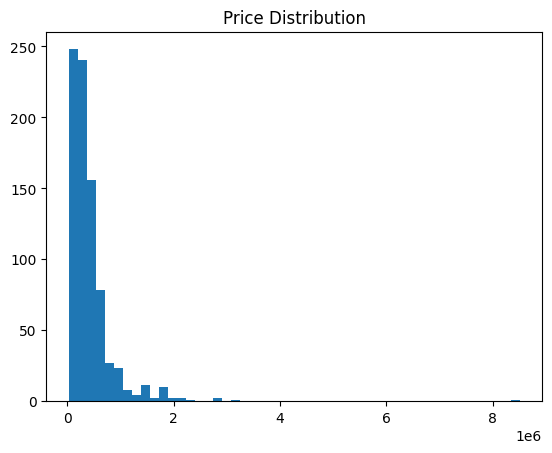

In [23]:
import matplotlib.pyplot as plt

plt.hist(df['Price'], bins=50)
plt.title('Price Distribution')
plt.show()

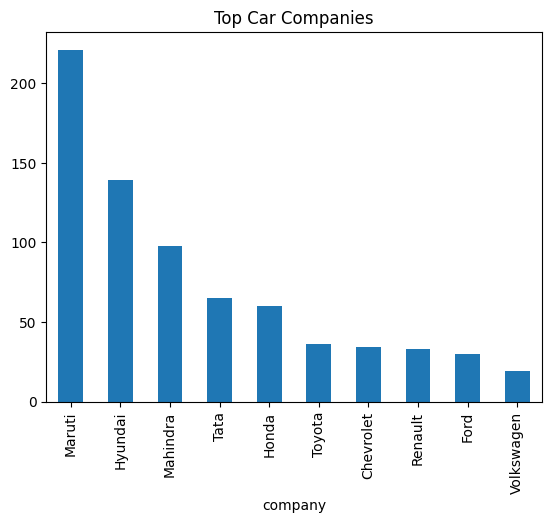

In [24]:
df['company'].value_counts().head(10).plot(kind='bar')
plt.title('Top Car Companies')
plt.show()

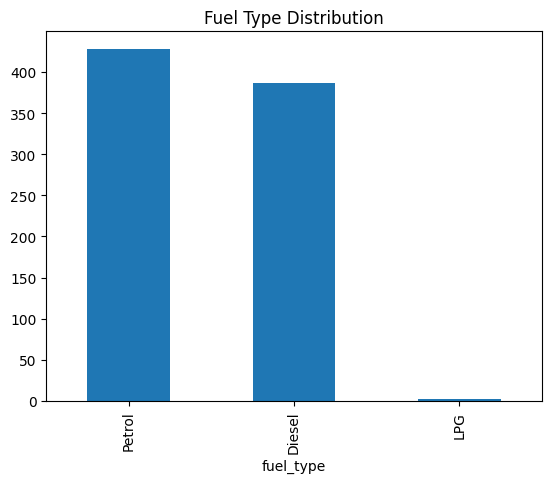

In [25]:
df['fuel_type'].value_counts().plot(kind='bar')
plt.title('Fuel Type Distribution')
plt.show()

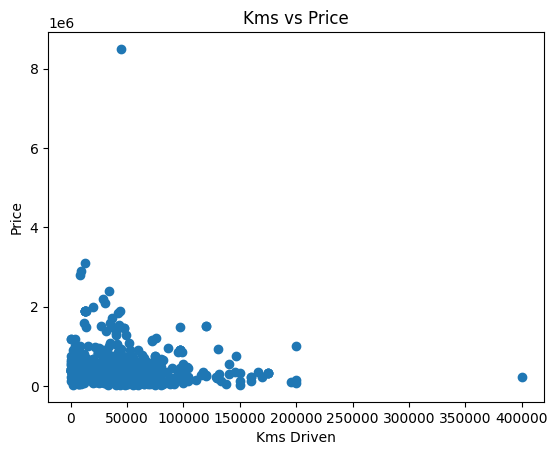

In [26]:
plt.scatter(df['kms_driven'], df['Price'])
plt.xlabel('Kms Driven')
plt.ylabel('Price')
plt.title('Kms vs Price')
plt.show()

conclusion:

Most cars are Petrol, showing higher demand
Luxury brands have higher average prices
Price generally decreases as kms driven increases
Some brands dominate listings → strong resale market